## Importing Libraries

In [4]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Machine Learning Model
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## Loading Dataset

In [5]:
import pandas as pd

df = pd.read_csv("/content/data.xls")

print(df.columns.tolist())
print(df.head())

['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'country']
                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930           

In [6]:
# Dataset information
print(df.info())

# Dataset shape
print("Shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

## Data Exploration

In [7]:
# Check missing values
print(df.isnull().sum())

# Statistical summary
print(df.describe())

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64
              price     bedrooms    bathrooms   sqft_living      sqft_lot  \
count  4.600000e+03  4600.000000  4600.000000   4600.000000  4.600000e+03   
mean   5.519630e+05     3.400870     2.160815   2139.346957  1.485252e+04   
std    5.638347e+05     0.908848     0.783781    963.206916  3.588444e+04   
min    0.000000e+00     0.000000     0.000000    370.000000  6.380000e+02   
25%    3.228750e+05     3.000000     1.750000   1460.000000  5.000750e+03   
50%    4.609435e+05     3.000000     2.250000   1980.000000  7.683000e+03   
75%    6.549625e+05     4.000000     2.500000   2620.000000  1.100125e+04   
max    2.659000e+07     9.000

## House Price Distribution

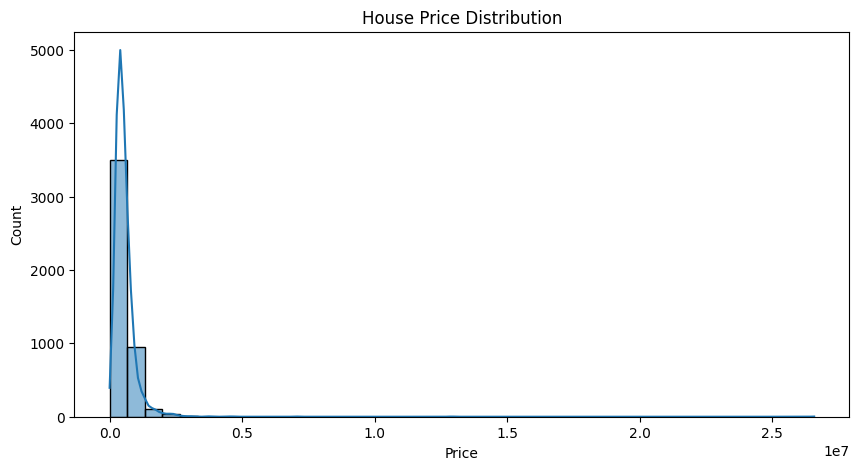

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['price'],
    bins=40,
    kde=True
)

plt.title("House Price Distribution")

plt.xlabel("Price")

plt.show()

## Correlation Heatmap

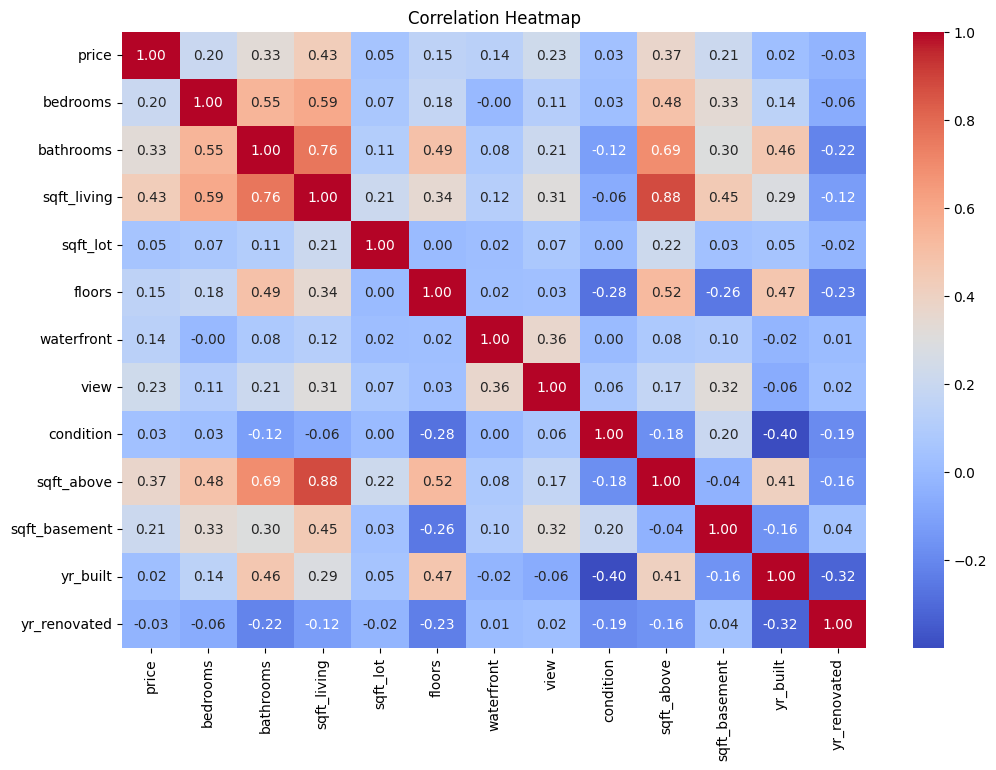

In [11]:
numeric_cols = [
    'price',
    'bedrooms',
    'bathrooms',
    'sqft_living',
    'sqft_lot',
    'floors',
    'waterfront',
    'view',
    'condition',
    'sqft_above',
    'sqft_basement',
    'yr_built',
    'yr_renovated'
]

plt.figure(figsize=(12,8))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

## Area vs Price

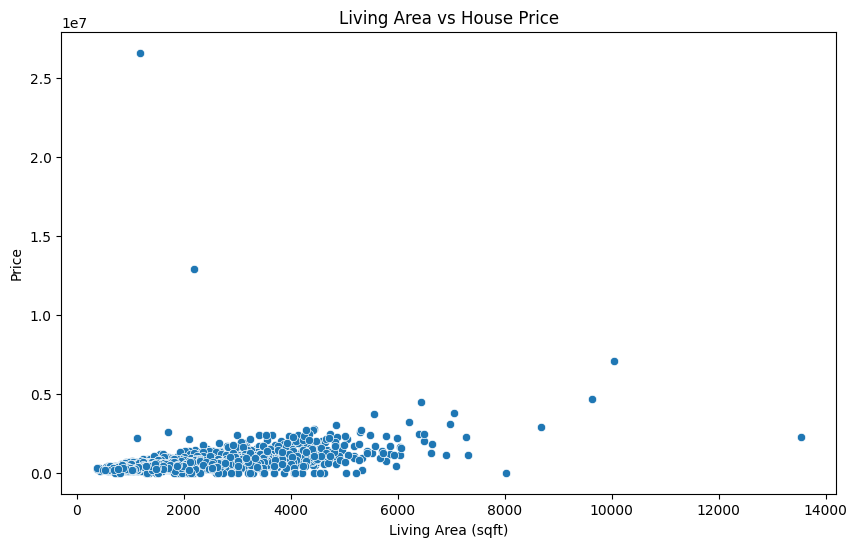

In [12]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='sqft_living',
    y='price',
    data=df
)

plt.title("Living Area vs House Price")

plt.xlabel("Living Area (sqft)")
plt.ylabel("Price")

plt.show()

## Top Cities by Average Price

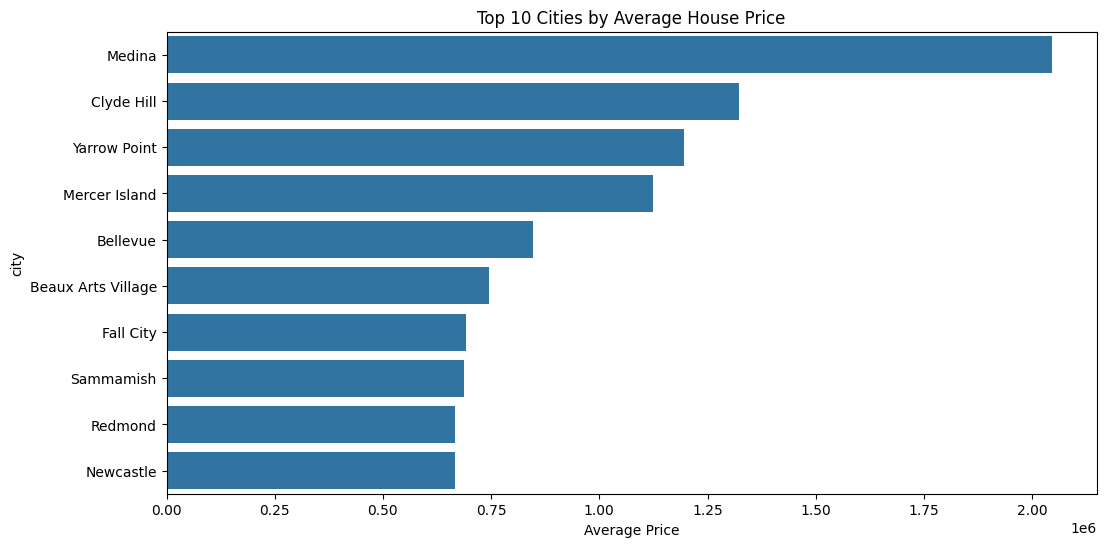

In [13]:
city_price = df.groupby(
    'city'
)['price'].mean().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=city_price.values,
    y=city_price.index
)

plt.title("Top 10 Cities by Average House Price")

plt.xlabel("Average Price")

plt.show()

## Feature Engineeing

In [14]:
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

## Encoding Categorcial Columns

In [15]:
categorical_cols = [
    'street',
    'city',
    'statezip',
    'country'
]

encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

## Define Features and Targets

In [16]:
X = df.drop(
    columns=['price','date']
)

y = df['price']

## Train Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Train Random Forest

In [18]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

RandomForestRegressor(n_estimators=200, random_state=42)

## Predictions

In [19]:
predictions = model.predict(X_test)

## Evaluation Metrics

In [21]:
mae = mean_absolute_error(
    y_test,
    predictions
)

mse = mean_squared_error(
    y_test,
    predictions
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 165100.64794544
MSE : 975783363656.3854
RMSE : 987817.4748689078
R2 Score : 0.04320550527917022


## Actual vs Predicted Prices

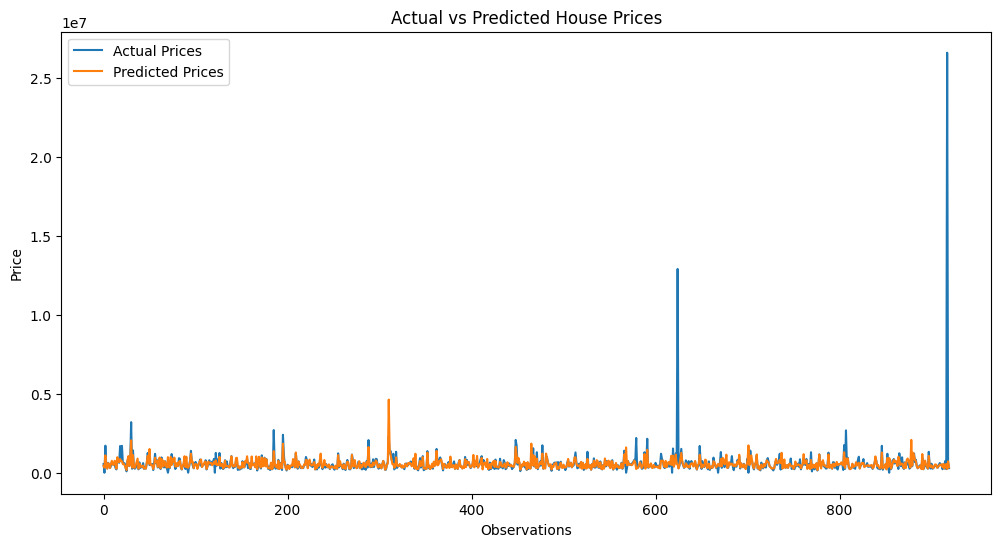

In [22]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label='Actual Prices'
)

plt.plot(
    predictions,
    label='Predicted Prices'
)

plt.title("Actual vs Predicted House Prices")

plt.xlabel("Observations")
plt.ylabel("Price")

plt.legend()

plt.show()

## Scatter Plot for Actual vs Prediction

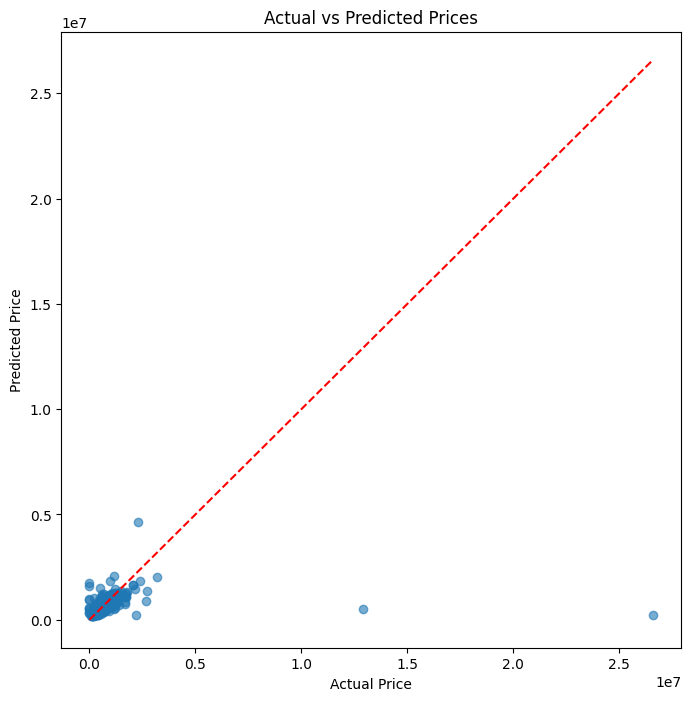

In [23]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    predictions,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.title("Actual vs Predicted Prices")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.show()

## Residual Plot

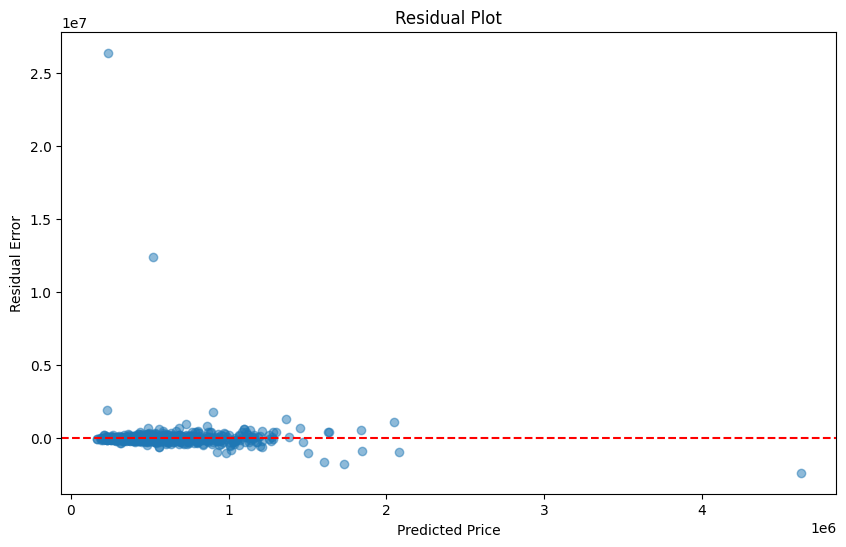

In [24]:
residuals = y_test - predictions

plt.figure(figsize=(10,6))

plt.scatter(
    predictions,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.title("Residual Plot")

plt.xlabel("Predicted Price")
plt.ylabel("Residual Error")

plt.show()

## Residual Distribution

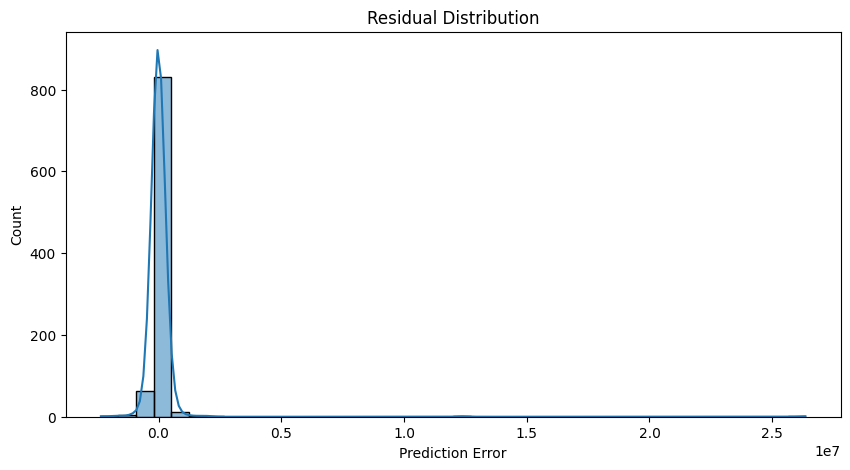

In [25]:
plt.figure(figsize=(10,5))

sns.histplot(
    residuals,
    kde=True,
    bins=40
)

plt.title("Residual Distribution")

plt.xlabel("Prediction Error")

plt.show()

## Feature Importance

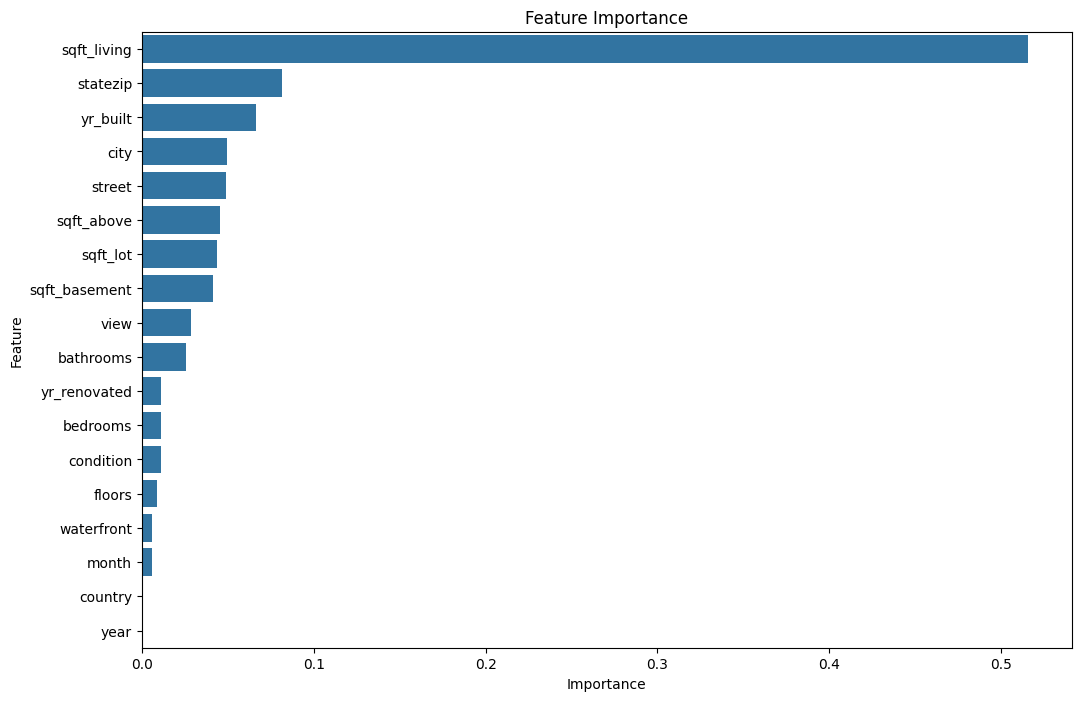

In [26]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(12,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")

plt.show()

## Model Summary

- The model achieved a Mean Absolute Error (MAE) of 165,100, indicating that predicted house prices deviated from actual prices by approximately $165,100 on average.
- The Root Mean Squared Error (RMSE) of 987,817 suggests the presence of some large prediction errors and outliers in the dataset.
- The R² Score of 0.043 indicates that the model explains only 4.3% of the variation in house prices, showing limited predictive capability.
- The results suggest that the current model was unable to capture the complex relationships influencing house prices effectively.
- Additional feature engineering, hyperparameter tuning, outlier treatment, and advanced models such as XGBoost, Gradient Boosting, or CatBoost may improve performance.
- Incorporating richer location-based features and market-related information could further enhance prediction accuracy.